# Branch B — Autoencoder Training
Run on GPU runtime in Google Colab.

In [1]:
# Cell 1 — Clone repo and set path
import os, sys

if not os.path.exists('/content/hallucination-detector'):
    !git clone https://github.com/theek-sh-nahh/hallucination-detector.git
else:
    !cd /content/hallucination-detector && git pull origin main

os.chdir('/content/hallucination-detector')
sys.path.insert(0, '/content/hallucination-detector')

print('src contents:', os.listdir('src'))
print('Ready.')

Cloning into 'hallucination-detector'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 59 (delta 29), reused 36 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 156.54 KiB | 6.81 MiB/s, done.
Resolving deltas: 100% (29/29), done.
src contents: ['fusion.py', 'confidence.py', 'autoencoder.py', 'lstm_model.py', 'preprocess.py', '__init__.py']
Ready.


In [2]:
# Cell 2 — Install dependencies
!pip install -q sentence-transformers
print('Done.')

Done.


In [3]:
# Cell 3 — Upload processed_data.zip
from google.colab import files
import zipfile, os

print('Upload processed_data.zip now:')
uploaded = files.upload()

os.makedirs('data/processed', exist_ok=True)
with zipfile.ZipFile('processed_data.zip', 'r') as z:
    z.extractall('data/processed')

print('Extracted:', os.listdir('data/processed'))

Upload processed_data.zip now:


Saving processed_data.zip to processed_data.zip
Extracted: ['y_test.npy', 'X_test.npy', 'y_train.npy', 'X_train.npy', 'X_val.npy', 'dataset.csv', 'y_val.npy']


In [4]:
# Cell 4 — Load data
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

X_train = np.load('data/processed/X_train.npy')
X_val   = np.load('data/processed/X_val.npy')
X_test  = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_val   = np.load('data/processed/y_val.npy')
y_test  = np.load('data/processed/y_test.npy')

print(f'X_train: {X_train.shape}')
print(f'Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}')

Device: cuda
X_train: (4116, 384)
Classes: {np.int64(0): np.int64(1811), np.int64(1): np.int64(1201), np.int64(2): np.int64(9), np.int64(3): np.int64(1095)}


In [5]:
# Cell 5 — Run AE hyperparameter search
from src.autoencoder import (
    get_factual_embeddings,
    run_ae_hyperparameter_search
)

# AE trains ONLY on factual samples — unsupervised
X_factual = get_factual_embeddings(X_train, y_train)

save_dir  = 'models/autoencoder'
os.makedirs(save_dir, exist_ok=True)

best_ae_config = run_ae_hyperparameter_search(
    X_factual,
    config_list=None,
    device=device,
    save_dir=save_dir
)
print(f'\nBest AE config: {best_ae_config}')

  Factual samples for AE training: 1811

AE HYPERPARAMETER SEARCH — 8 configurations

[1/8] Config: {'lr': 0.001, 'latent_dim': 16, 'batch_size': 32, 'epochs': 50, 'patience': 7, 'dropout': 0.2}
  AE train batches: 57

  Training AE for up to 50 epochs...
  LR=0.001, Latent=16, Batch=32
-------------------------------------------------------
  Epoch 001 | Train Loss: 0.002481
  ✓ Best AE saved (loss=0.002481)
  Epoch 002 | Train Loss: 0.002236
  ✓ Best AE saved (loss=0.002236)
  Epoch 003 | Train Loss: 0.002223
  ✓ Best AE saved (loss=0.002223)
  Epoch 004 | Train Loss: 0.002219
  ✓ Best AE saved (loss=0.002219)
  Epoch 005 | Train Loss: 0.002215
  ✓ Best AE saved (loss=0.002215)
  Epoch 006 | Train Loss: 0.002213
  ✓ Best AE saved (loss=0.002213)
  Epoch 007 | Train Loss: 0.002212
  ✓ Best AE saved (loss=0.002212)
  Epoch 008 | Train Loss: 0.002210
  ✓ Best AE saved (loss=0.002210)
  Epoch 009 | Train Loss: 0.002210
  ✓ Best AE saved (loss=0.002210)
  Epoch 010 | Train Loss: 0.002208


In [6]:
# Cell 6 — Train final AE with best config for more epochs
from src.autoencoder import (
    HallucinationAutoencoder,
    prepare_ae_dataloader,
    train_autoencoder
)

final_ae_config = best_ae_config.copy()
final_ae_config['epochs']   = 100
final_ae_config['patience'] = 10
final_ae_config['dropout']  = 0.2

ae_loader = prepare_ae_dataloader(
    X_factual,
    batch_size=final_ae_config['batch_size']
)

ae_model = HallucinationAutoencoder(
    input_dim=384,
    latent_dim=final_ae_config['latent_dim'],
    dropout=final_ae_config['dropout']
).to(device)

ae_history = train_autoencoder(
    ae_model, ae_loader, final_ae_config,
    device,
    save_path=f'{save_dir}/ae_final.pt'
)
print('AE training complete.')

  AE train batches: 57

  Training AE for up to 100 epochs...
  LR=0.001, Latent=16, Batch=32
-------------------------------------------------------
  Epoch 001 | Train Loss: 0.002469
  ✓ Best AE saved (loss=0.002469)
  Epoch 002 | Train Loss: 0.002234
  ✓ Best AE saved (loss=0.002234)
  Epoch 003 | Train Loss: 0.002222
  ✓ Best AE saved (loss=0.002222)
  Epoch 004 | Train Loss: 0.002217
  ✓ Best AE saved (loss=0.002217)
  Epoch 005 | Train Loss: 0.002214
  ✓ Best AE saved (loss=0.002214)
  Epoch 006 | Train Loss: 0.002212
  ✓ Best AE saved (loss=0.002212)
  Epoch 007 | Train Loss: 0.002210
  ✓ Best AE saved (loss=0.002210)
  Epoch 008 | Train Loss: 0.002210
  Epoch 009 | Train Loss: 0.002209
  ✓ Best AE saved (loss=0.002209)
  Epoch 010 | Train Loss: 0.002207
  ✓ Best AE saved (loss=0.002207)
  Epoch 011 | Train Loss: 0.002207
  ✓ Best AE saved (loss=0.002207)
  Epoch 012 | Train Loss: 0.002205
  ✓ Best AE saved (loss=0.002205)
  Epoch 013 | Train Loss: 0.002205
  Epoch 014 | Train L

In [7]:
# Cell 7 — Compute threshold and verify anomaly detection
from src.autoencoder import compute_threshold, eval_ae

# Get hallucinated samples from val set for threshold computation
X_hal_val = X_val[y_val == 1]
X_fac_val = X_val[y_val == 0]

print(f'Factual val samples:      {X_fac_val.shape[0]}')
print(f'Hallucinated val samples: {X_hal_val.shape[0]}')

threshold, stats = compute_threshold(
    ae_model, X_fac_val, X_hal_val, device
)

# Quick sanity check
all_errors  = eval_ae(ae_model, X_val, device)
predictions = (all_errors > threshold).astype(int)
actual      = (y_val == 1).astype(int)

from sklearn.metrics import classification_report
print('\nAE binary classification (factual vs hallucinated):')
print(classification_report(actual, predictions,
      target_names=['factual', 'hallucinated']))

Factual val samples:      388
Hallucinated val samples: 258

  Factual error:      0.002192 ± 0.000205
  Hallucinated error: 0.002177 ± 0.000183
  Threshold:          0.002184

AE binary classification (factual vs hallucinated):
              precision    recall  f1-score   support

     factual       0.71      0.52      0.60       625
hallucinated       0.29      0.48      0.37       258

    accuracy                           0.51       883
   macro avg       0.50      0.50      0.48       883
weighted avg       0.59      0.51      0.53       883



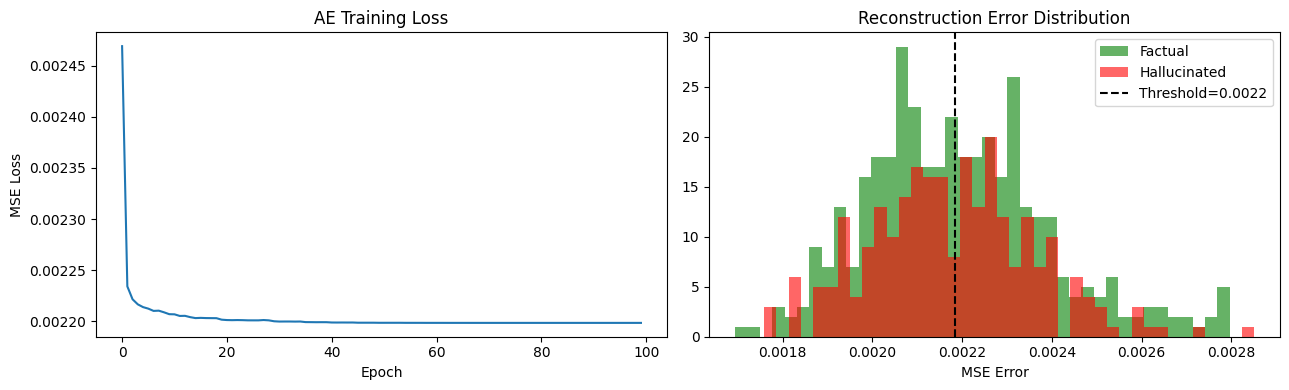

Plot saved.


In [8]:
# Cell 8 — Plot AE training loss and error distributions
import matplotlib.pyplot as plt
from src.autoencoder import eval_ae

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss curve
ax1.plot(ae_history['train_loss'])
ax1.set_title('AE Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')

# Error distribution — key diagnostic plot
fac_errors = eval_ae(ae_model, X_val[y_val == 0], device)
hal_errors = eval_ae(ae_model, X_val[y_val == 1], device)

ax2.hist(fac_errors, bins=40, alpha=0.6, label='Factual',      color='green')
ax2.hist(hal_errors, bins=40, alpha=0.6, label='Hallucinated', color='red')
ax2.axvline(threshold, color='black', linestyle='--', label=f'Threshold={threshold:.4f}')
ax2.set_title('Reconstruction Error Distribution')
ax2.set_xlabel('MSE Error')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/ae_plot.png', dpi=150)
plt.show()
print('Plot saved.')

In [12]:
# Cell 9 — Save fusion params and download everything
import json, shutil
from google.colab import files
from src.fusion import save_fusion_params

# Save the threshold and AE error range for use in the app
all_train_errors = eval_ae(ae_model, X_factual, device)
ae_min = float(all_train_errors.min())
ae_max = float(all_train_errors.max())

save_fusion_params(
    ae_min=ae_min,
    ae_max=ae_max,
    lstm_weight=0.75,
    ae_weight=0.25,
    save_dir='models'
)

# Also save threshold separately
with open('models/ae_threshold.json', 'w') as f:
    json.dump({'threshold': float(threshold), **stats}, f, indent=2)

print('Fusion params saved.')

# Download
shutil.make_archive('ae_model', 'zip', 'models/autoencoder')
shutil.copy('models/fusion_params.json', '.')
shutil.copy('models/ae_threshold.json', '.')

files.download('ae_model.zip')
files.download('fusion_params.json')
files.download('ae_threshold.json')
print('Downloads started.')

  Fusion params saved to models/fusion_params.json
Fusion params saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started.


In [14]:
# Mount Google Drive and save everything there
from google.colab import drive
drive.mount('/content/drive')

import shutil, os, json

# Create a folder in your Drive
save_dir = '/content/drive/MyDrive/hallucination-detector-models'
os.makedirs(f'{save_dir}/lstm', exist_ok=True)
os.makedirs(f'{save_dir}/autoencoder', exist_ok=True)

# Save AE model and plots
shutil.copy('models/autoencoder/ae_final.pt',  f'{save_dir}/autoencoder/ae_final.pt')
shutil.copy('models/autoencoder/ae_plot.png',  f'{save_dir}/autoencoder/ae_plot.png')
shutil.copy('models/fusion_params.json',        f'{save_dir}/fusion_params.json')
shutil.copy('models/ae_threshold.json',         f'{save_dir}/ae_threshold.json')

print("Saved to Google Drive:")
print(os.listdir(f'{save_dir}/autoencoder'))
print(os.listdir(save_dir))

Mounted at /content/drive
Saved to Google Drive:
['ae_final.pt', 'ae_plot.png']
['lstm', 'autoencoder', 'fusion_params.json', 'ae_threshold.json']
